# Threshold Optimization & Calibration

Calibration check (reliability diagram, Brier score) for XGBoost and LightGBM,
followed by cost-based threshold optimization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from churn.config import PROCESSED_DIR
from churn.modeling.train import get_xy, build_xgboost, build_lightgbm
from churn.evaluation.threshold import get_calibration_data, run_threshold_analysis

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train_balanced.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_selected.parquet")
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)

xgb = build_xgboost().fit(X_train, y_train)
lgbm = build_lightgbm().fit(X_train, y_train)

proba_xgb = xgb.predict_proba(X_test)[:, 1]
proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

## Calibration — reliability diagrams + Brier score

XGBoost Brier score: 0.0657
LightGBM Brier score: 0.0621


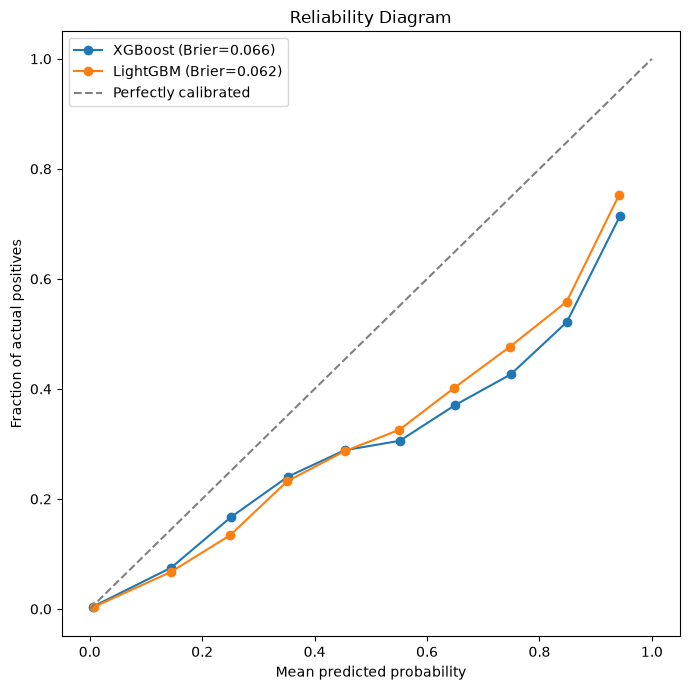

In [2]:
prob_true_xgb, prob_pred_xgb, brier_xgb = get_calibration_data(y_test, proba_xgb)
prob_true_lgbm, prob_pred_lgbm, brier_lgbm = get_calibration_data(y_test, proba_lgbm)

print(f"XGBoost Brier score: {brier_xgb:.4f}")
print(f"LightGBM Brier score: {brier_lgbm:.4f}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(prob_pred_xgb, prob_true_xgb, marker="o", label=f"XGBoost (Brier={brier_xgb:.3f})")
ax.plot(prob_pred_lgbm, prob_true_lgbm, marker="o", label=f"LightGBM (Brier={brier_lgbm:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual positives")
ax.set_title("Reliability Diagram")
ax.legend()
plt.tight_layout()
save_fig(fig, "13_reliability_diagram")
plt.show()

**Interpretation — Calibration**

- **Brier score:** LightGBM (0.0621) is slightly better calibrated than XGBoost (0.0657).

- **Reliability diagram:** Both models mostly **overestimate churn probability**, especially at higher predicted probabilities.

- This is expected because the models were trained on **SMOTE-balanced data (50/50)** but tested on the real ~8.88% churn distribution, which can make predicted probabilities too high.

- **LightGBM is slightly better calibrated**, consistent with its lower Brier score.

## Cost-based threshold optimization (hypothetical cost ratios)

The ratios below (2:1,
5:1, 10:1 — false negative cost : false positive cost) are illustrative placeholders to
show how the optimal threshold shifts with the cost tradeoff, not a final recommendation.

In [3]:
print("--- XGBoost ---")
results_xgb = run_threshold_analysis(y_test, proba_xgb, "XGBoost")
print("\n--- LightGBM ---")
results_lgbm = run_threshold_analysis(y_test, proba_lgbm, "LightGBM")

--- XGBoost ---


[XGBoost] cost ratio 2:1 -> optimal threshold = 0.58, FN=3158, FP=8171, cost=14487


[XGBoost] cost ratio 5:1 -> optimal threshold = 0.23, FN=641, FP=15093, cost=18298


[XGBoost] cost ratio 10:1 -> optimal threshold = 0.18, FN=548, FP=15991, cost=21471

--- LightGBM ---


[LightGBM] cost ratio 2:1 -> optimal threshold = 0.54, FN=3082, FP=8183, cost=14347


[LightGBM] cost ratio 5:1 -> optimal threshold = 0.28, FN=719, FP=14688, cost=18283


[LightGBM] cost ratio 10:1 -> optimal threshold = 0.20, FN=535, FP=16054, cost=21404


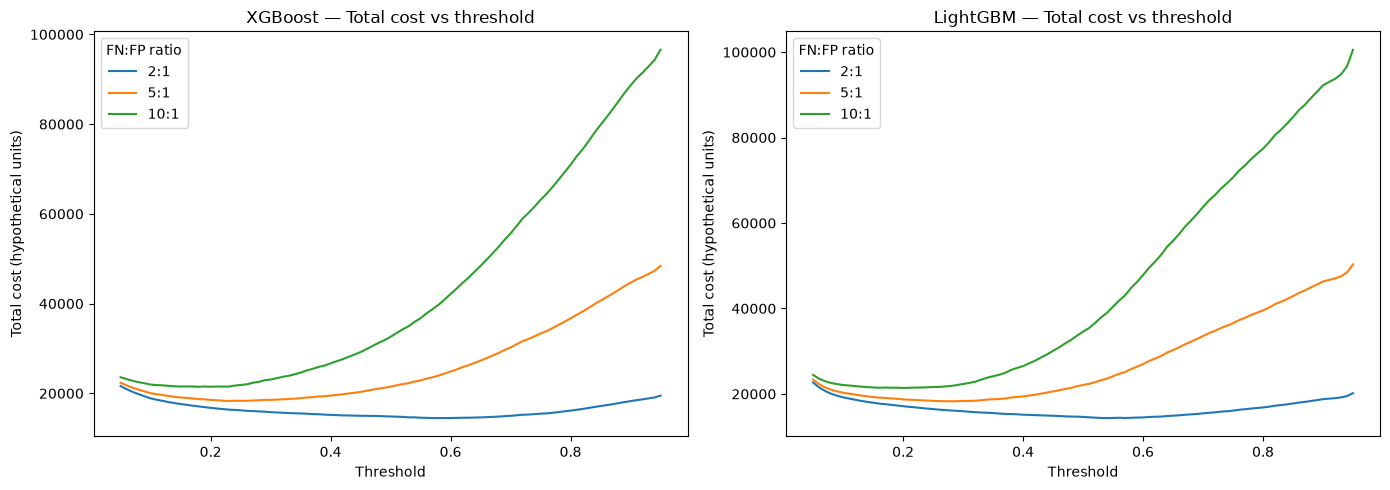

In [4]:
from churn.evaluation.threshold import find_optimal_threshold, COST_RATIOS, THRESHOLD_GRID

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ratio in COST_RATIOS:
    df_xgb = find_optimal_threshold(y_test, proba_xgb, fn_cost=ratio, fp_cost=1)
    df_lgbm = find_optimal_threshold(y_test, proba_lgbm, fn_cost=ratio, fp_cost=1)
    axes[0].plot(df_xgb["threshold"], df_xgb["total_cost"], label=f"{ratio}:1")
    axes[1].plot(df_lgbm["threshold"], df_lgbm["total_cost"], label=f"{ratio}:1")

axes[0].set_title("XGBoost — Total cost vs threshold")
axes[1].set_title("LightGBM — Total cost vs threshold")
for ax in axes:
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Total cost (hypothetical units)")
    ax.legend(title="FN:FP ratio")
plt.tight_layout()
save_fig(fig, "14_cost_curves")
plt.show()

**Observations — Threshold optimization**

- As the cost of missing a churner increases, the optimal threshold **decreases**, so more customers are flagged as at risk.

- Both models behave similarly, with LightGBM choosing slightly lower thresholds and therefore being more aggressive.

- These thresholds are **model scores, not true churn probabilities**, because SMOTE causes the predicted probabilities to be inflated.

**Working threshold assumption:**  LightGBM at the 5:1 cost ratio, threshold =
**0.28**, is adopted as the working assumption for subsequent analysis

In [5]:
import pandas as pd
from churn.config import PROCESSED_DIR
from churn.modeling.train import get_xy, build_xgboost, build_lightgbm
from churn.evaluation.threshold import get_calibration_data, run_threshold_analysis

train = pd.read_parquet(PROCESSED_DIR / "train_balanced.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_selected.parquet")
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)

xgb = build_xgboost().fit(X_train, y_train)
lgbm = build_lightgbm().fit(X_train, y_train)
proba_xgb = xgb.predict_proba(X_test)[:, 1]
proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

_, _, brier_xgb = get_calibration_data(y_test, proba_xgb)
_, _, brier_lgbm = get_calibration_data(y_test, proba_lgbm)
print(f"XGBoost Brier: {brier_xgb:.4f}")
print(f"LightGBM Brier: {brier_lgbm:.4f}")

print("\n--- XGBoost ---")
run_threshold_analysis(y_test, proba_xgb, "XGBoost")
print("\n--- LightGBM ---")
run_threshold_analysis(y_test, proba_lgbm, "LightGBM")

XGBoost Brier: 0.0657
LightGBM Brier: 0.0621

--- XGBoost ---


[XGBoost] cost ratio 2:1 -> optimal threshold = 0.58, FN=3158, FP=8171, cost=14487


[XGBoost] cost ratio 5:1 -> optimal threshold = 0.23, FN=641, FP=15093, cost=18298


[XGBoost] cost ratio 10:1 -> optimal threshold = 0.18, FN=548, FP=15991, cost=21471

--- LightGBM ---


[LightGBM] cost ratio 2:1 -> optimal threshold = 0.54, FN=3082, FP=8183, cost=14347


[LightGBM] cost ratio 5:1 -> optimal threshold = 0.28, FN=719, FP=14688, cost=18283


[LightGBM] cost ratio 10:1 -> optimal threshold = 0.20, FN=535, FP=16054, cost=21404


{'2:1': {'optimal_threshold': 0.5400000000000001,
  'total_cost': 14347.0,
  'fn': 3082,
  'fp': 8183,
  'tp': 7393},
 '5:1': {'optimal_threshold': 0.28,
  'total_cost': 18283.0,
  'fn': 719,
  'fp': 14688,
  'tp': 9756},
 '10:1': {'optimal_threshold': 0.2,
  'total_cost': 21404.0,
  'fn': 535,
  'fp': 16054,
  'tp': 9940}}